Lưu Văn Thành Huy . 22KTMT1 .STT: 

## Phân loại Fashion-MNIST từ file CSV (MLP)

**Mục tiêu:** Từ dữ liệu CSV gồm `label` + 784 pixel (ảnh 28×28), xây dựng và huấn luyện **mạng nơ-ron nhiều lớp (MLP)** để phân loại 10 lớp.

**Yêu cầu bài:**
- Tiền xử lý dữ liệu (đọc CSV, tách `X/y`, chuẩn hoá)
- Xây dựng kiến trúc MLP phù hợp
- Chọn hàm mất mát (loss)
- Chọn tối ưu (optimizer) và siêu tham số
- Huấn luyện và đánh giá trên train & test
- Trực quan hoá 5–10 mẫu ảnh và dự đoán

**Lưu ý môi trường:** Cần cài các thư viện: `numpy`, `matplotlib`, `tensorflow` (và `pandas` là *tuỳ chọn*).

In [1]:
 # Cell 1: Import thư viện + cấu hình chung

from __future__ import annotations

import os
import random
from dataclasses import dataclass
from pathlib import Path

import numpy as np

# TensorFlow/Keras dùng để xây dựng MLP
import tensorflow as tf


@dataclass(frozen=True)
class Config:
    # Đường dẫn tới dataset CSV trong workspace
    train_csv: Path = Path("data") / "data" / "fashion-mnist_train.csv"
    test_csv: Path = Path("data") / "data" / "fashion-mnist_test.csv"

    # Siêu tham số huấn luyện
    seed: int = 42
    epochs: int = 15
    batch_size: int = 128
    learning_rate: float = 1e-3

    # Kiến trúc MLP
    hidden_units: tuple[int, ...] = (256, 128)
    dropout: float = 0.3

    # Chia tập validation từ train
    val_ratio: float = 0.1

    # Số lớp
    n_classes: int = 10


cfg = Config()

# Map nhãn (0..9) theo Fashion-MNIST chuẩn
FASHION_MNIST_LABELS = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot",
]


def set_seed(seed: int) -> None:
    """Cố định seed để kết quả ổn định hơn."""

    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)


set_seed(cfg.seed)
print("Using TensorFlow:", tf.__version__)

Using TensorFlow: 2.20.0


In [2]:
# Cell 2: Đọc dữ liệu CSV + kiểm tra nhanh cấu trúc

from collections import Counter


def load_fashion_mnist_csv(path: Path) -> tuple[np.ndarray, np.ndarray]:
    """Đọc file CSV Fashion-MNIST.

    File có dạng: cột đầu là `label`, sau đó là `pixel1..pixel784`.
    Hàm này ưu tiên dùng pandas (nếu có) để đọc nhanh; nếu không có pandas
    thì dùng thư viện chuẩn `csv`.
    """

    # Cách 1: dùng pandas nếu cài sẵn
    try:
        import pandas as pd  # type: ignore

        df = pd.read_csv(path)
        y = df.iloc[:, 0].to_numpy(dtype=np.int64)
        x = df.iloc[:, 1:].to_numpy(dtype=np.float32)
        return x, y
    except Exception:
        pass

    # Cách 2: fallback bằng csv stdlib
    import csv

    y_list: list[int] = []
    x_list: list[list[float]] = []

    with path.open("r", encoding="utf-8", newline="") as f:
        reader = csv.reader(f)
        header = next(reader)
        if not header or header[0] != "label":
            raise ValueError(f"Header không đúng định dạng: {header[:10]}")

        for row in reader:
            # row[0] là nhãn, row[1:] là 784 pixel
            y_list.append(int(row[0]))
            x_list.append([float(v) for v in row[1:]])

    x = np.asarray(x_list, dtype=np.float32)
    y = np.asarray(y_list, dtype=np.int64)
    return x, y


# Đọc train và test
x_train_raw, y_train = load_fashion_mnist_csv(cfg.train_csv)
x_test_raw, y_test = load_fashion_mnist_csv(cfg.test_csv)

print("Train X:", x_train_raw.shape, "y:", y_train.shape)
print("Test  X:", x_test_raw.shape, "y:", y_test.shape)

# Kiểm tra nhanh phân bố nhãn
train_counts = Counter(y_train.tolist())
test_counts = Counter(y_test.tolist())
print("Train label counts:", dict(sorted(train_counts.items())))
print("Test  label counts:", dict(sorted(test_counts.items())))

# Kiểm tra số pixel: 784 (28x28)
assert x_train_raw.shape[1] == 784, "Dữ liệu pixel không đúng 784 cột"

Train X: (60000, 784) y: (60000,)
Test  X: (10000, 784) y: (10000,)
Train label counts: {0: 6000, 1: 6000, 2: 6000, 3: 6000, 4: 6000, 5: 6000, 6: 6000, 7: 6000, 8: 6000, 9: 6000}
Test  label counts: {0: 1000, 1: 1000, 2: 1000, 3: 1000, 4: 1000, 5: 1000, 6: 1000, 7: 1000, 8: 1000, 9: 1000}


In [3]:
# Cell 3: Tiền xử lý (chuẩn hoá) + tách validation


def preprocess_x(x: np.ndarray) -> np.ndarray:
    """Chuẩn hoá pixel từ [0..255] về [0..1]."""

    x = x.astype(np.float32)
    x = x / 255.0
    return x


x_train = preprocess_x(x_train_raw)
x_test = preprocess_x(x_test_raw)

# Tách một phần train làm validation để theo dõi overfitting
n_train = x_train.shape[0]
idx = np.arange(n_train)
np.random.shuffle(idx)

val_size = int(round(n_train * cfg.val_ratio))
val_idx = idx[:val_size]
train_idx = idx[val_size:]

x_val, y_val = x_train[val_idx], y_train[val_idx]
x_tr, y_tr = x_train[train_idx], y_train[train_idx]

print("Train split:", x_tr.shape, y_tr.shape)
print("Val   split:", x_val.shape, y_val.shape)
print("Test  split:", x_test.shape, y_test.shape)

Train split: (54000, 784) (54000,)
Val   split: (6000, 784) (6000,)
Test  split: (10000, 784) (10000,)


In [4]:
# Cell 4: Xây dựng mô hình MLP (mạng nơ-ron nhiều lớp)


def build_mlp_model(
    input_dim: int,
    n_classes: int,
    hidden_units: tuple[int, ...],
    dropout: float,
    learning_rate: float,
) -> tf.keras.Model:
    """Tạo mô hình MLP cho bài toán phân loại 10 lớp.

    - Input: vector 784 chiều (ảnh 28x28 đã flatten)
    - Hidden: Dense(ReLU) nhiều lớp
    - Output: Dense(softmax) với 10 lớp
    """

    model = tf.keras.Sequential(name="mlp_fashion_mnist")
    model.add(tf.keras.layers.Input(shape=(input_dim,)))

    for units in hidden_units:
        model.add(tf.keras.layers.Dense(units, activation="relu"))
        if dropout and dropout > 0:
            model.add(tf.keras.layers.Dropout(dropout))

    model.add(tf.keras.layers.Dense(n_classes, activation="softmax"))

    # Loss: dùng SparseCategoricalCrossentropy vì y là nhãn int (0..9), không one-hot
    loss_fn = tf.keras.losses.SparseCategoricalCrossentropy()

    # Optimizer: Adam là lựa chọn phổ biến, ổn định cho bài toán này
    optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)

    model.compile(optimizer=optimizer, loss=loss_fn, metrics=["accuracy"])
    return model


model = build_mlp_model(
    input_dim=x_tr.shape[1],
    n_classes=cfg.n_classes,
    hidden_units=cfg.hidden_units,
    dropout=cfg.dropout,
    learning_rate=cfg.learning_rate,
)

model.summary()

Model: "mlp_fashion_mnist"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 235,146 (918.54 KB)

 Trainable params: 235,146 (918.54 KB)

 Non-trainable params: 0 (0.00 B)

In [5]:
# Cell 5: Huấn luyện mô hình

# (Tuỳ chọn) EarlyStopping giúp dừng sớm khi val_loss không cải thiện,
# tránh overfitting và tiết kiệm thời gian chạy.
early_stop_cb = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True,
)

history = model.fit(
    x_tr,
    y_tr,
    validation_data=(x_val, y_val),
    epochs=cfg.epochs,
    batch_size=cfg.batch_size,
    verbose=1,
    callbacks=[early_stop_cb],
)

Epoch 1/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7719 - loss: 0.6403 - val_accuracy: 0.8542 - val_loss: 0.3995
Epoch 2/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8374 - loss: 0.4494 - val_accuracy: 0.8652 - val_loss: 0.3678
Epoch 3/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8534 - loss: 0.4056 - val_accuracy: 0.8748 - val_loss: 0.3439
Epoch 4/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8610 - loss: 0.3833 - val_accuracy: 0.8817 - val_loss: 0.3309
Epoch 5/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8674 - loss: 0.3663 - val_accuracy: 0.8820 - val_loss: 0.3229
Epoch 6/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8734 - loss: 0.3502 - val_accuracy: 0.8833 - val_loss: 0.3199
Epoch 7/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8758 - loss: 0.3384 - val_accuracy: 0.8845 - val_loss: 0.3129
Epoch 8/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8799 - loss: 0.3285 - val_accuracy: 0.

In [6]:
# Cell 6: Đánh giá hiệu năng (train/test) + Confusion Matrix


def confusion_matrix_np(y_true: np.ndarray, y_pred: np.ndarray, n_classes: int) -> np.ndarray:
    """Tính confusion matrix bằng numpy (không cần sklearn)."""

    cm = np.zeros((n_classes, n_classes), dtype=np.int64)
    for t, p in zip(y_true, y_pred):
        cm[int(t), int(p)] += 1
    return cm


# Đánh giá trên train (toàn bộ) và test
train_loss, train_acc = model.evaluate(x_train, y_train, verbose=0)
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)

print("=== Evaluation ===")
print(f"Train: loss={train_loss:.4f}  acc={train_acc:.4f}")
print(f"Test : loss={test_loss:.4f}  acc={test_acc:.4f}")

# Dự đoán trên test
probs_test = model.predict(x_test, verbose=0)
y_pred_test = np.argmax(probs_test, axis=1)

cm = confusion_matrix_np(y_test, y_pred_test, cfg.n_classes)
print("\nConfusion matrix shape:", cm.shape)

# Accuracy theo từng lớp (per-class accuracy)
per_class_acc = cm.diagonal() / np.maximum(cm.sum(axis=1), 1)
for i, acc in enumerate(per_class_acc):
    print(f"Class {i:>2} ({FASHION_MNIST_LABELS[i]:<12}): acc={acc:.4f}")

=== Evaluation ===
Train: loss=0.2392  acc=0.9109
Test : loss=0.3004  acc=0.8890

Confusion matrix shape: (10, 10)
Class  0 (T-shirt/top ): acc=0.8590
Class  1 (Trouser     ): acc=0.9830
Class  2 (Pullover    ): acc=0.7470
Class  3 (Dress       ): acc=0.9140
Class  4 (Coat        ): acc=0.8470
Class  5 (Sandal      ): acc=0.9600
Class  6 (Shirt       ): acc=0.7060
Class  7 (Sneaker     ): acc=0.9170
Class  8 (Bag         ): acc=0.9820
Class  9 (Ankle boot  ): acc=0.9750


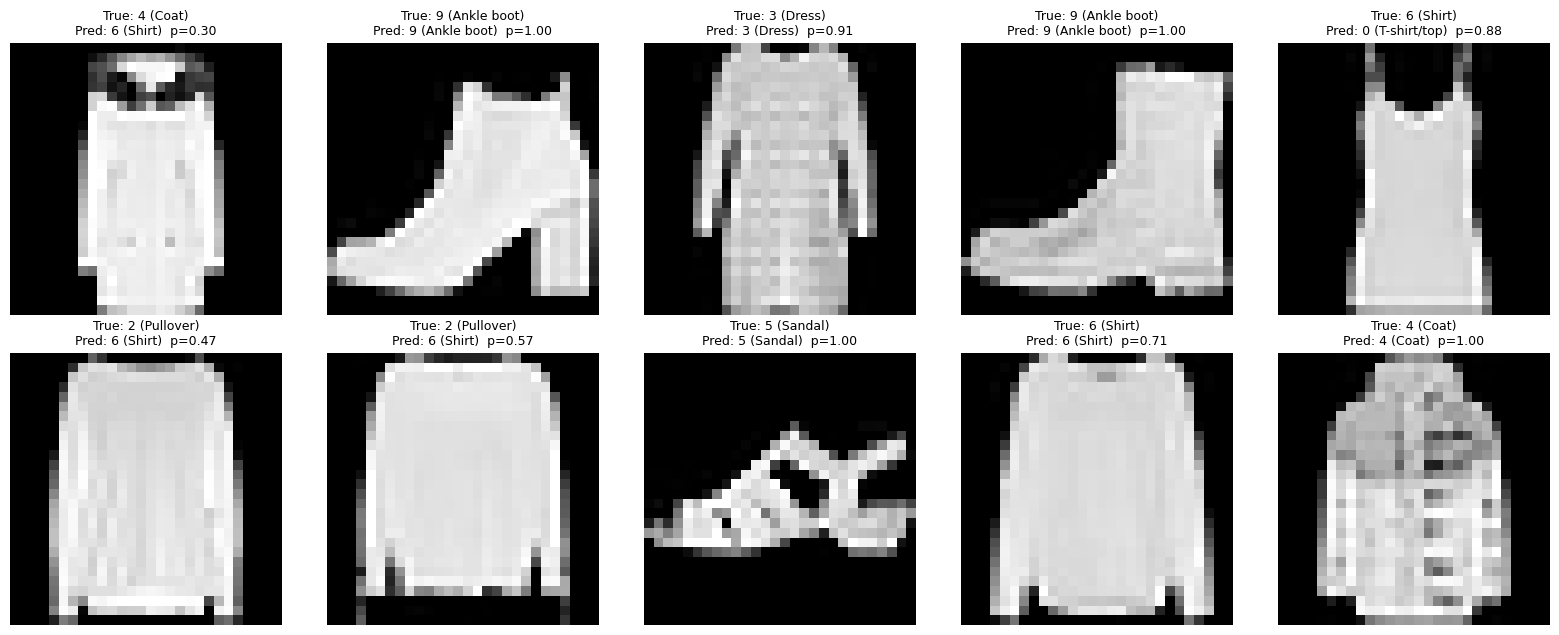

In [7]:
# Cell 7: Trực quan hoá 5–10 mẫu ảnh + dự đoán

import matplotlib.pyplot as plt


def visualize_predictions(
    x: np.ndarray,
    y_true: np.ndarray,
    y_pred: np.ndarray,
    probs: np.ndarray,
    n_samples: int = 10,
) -> None:
    """Chọn ngẫu nhiên n_samples mẫu, hiển thị ảnh và kết quả dự đoán."""

    n_samples = int(max(5, min(n_samples, x.shape[0])))
    idx = np.random.choice(x.shape[0], size=n_samples, replace=False)

    cols = 5
    rows = int(np.ceil(n_samples / cols))

    plt.figure(figsize=(cols * 3.2, rows * 3.2))

    for k, j in enumerate(idx, start=1):
        img = x[j].reshape(28, 28)
        t = int(y_true[j])
        p = int(y_pred[j])
        conf = float(np.max(probs[j]))

        title = (
            f"True: {t} ({FASHION_MNIST_LABELS[t]})\n"
            f"Pred: {p} ({FASHION_MNIST_LABELS[p]})  p={conf:.2f}"
        )

        ax = plt.subplot(rows, cols, k)
        ax.imshow(img, cmap="gray")
        ax.set_title(title, fontsize=9)
        ax.axis("off")

    plt.tight_layout()
    plt.show()


visualize_predictions(
    x_test,
    y_test,
    y_pred_test,
    probs_test,
    n_samples=10,  # đổi 5..10 tuỳ yêu cầu
)

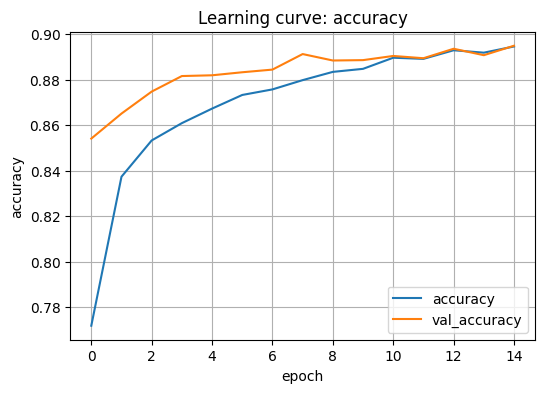

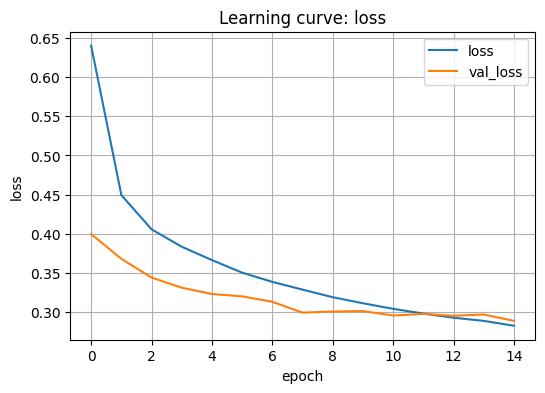

In [8]:
# (Tuỳ chọn) Cell 8: Vẽ learning curves (loss/accuracy theo epoch)


def plot_history(hist: tf.keras.callbacks.History) -> None:
    import matplotlib.pyplot as plt

    metrics = [k for k in hist.history.keys() if not k.startswith("val_")]
    for m in metrics:
        plt.figure(figsize=(6, 4))
        plt.plot(hist.history[m], label=m)
        if f"val_{m}" in hist.history:
            plt.plot(hist.history[f"val_{m}"], label=f"val_{m}")
        plt.xlabel("epoch")
        plt.ylabel(m)
        plt.title(f"Learning curve: {m}")
        plt.legend()
        plt.grid(True)
        plt.show()


plot_history(history)

## Ghi chú cuối cùng (tóm tắt theo yêu cầu đề)

### 1) Tiền xử lý dữ liệu
- Dữ liệu dạng CSV: cột đầu là `label` (0–9), các cột còn lại là `pixel1..pixel784` (tổng 784 pixel = ảnh 28×28 dạng grayscale).
- Tách dữ liệu: `X` = 784 pixel, `y` = nhãn lớp.
- Chuẩn hoá đầu vào: đưa giá trị pixel từ [0..255] về [0..1] bằng phép chia `X = X/255.0`.
- Chia tập validation từ train (10%) để theo dõi quá trình học và hạn chế overfitting.

### 2) Lựa chọn & xây dựng cấu trúc mạng nơ-ron (MLP)
- Chọn mô hình MLP vì dữ liệu đầu vào đã được “flatten” thành vector 784 chiều.
- Kiến trúc dùng trong bài:
  - Input: 784
  - Hidden: Dense(256, ReLU) → Dropout(0.3) → Dense(128, ReLU) → Dropout(0.3)
  - Output: Dense(10, Softmax)

### 3) Lựa chọn hàm mất mát (Loss)
- Dùng `SparseCategoricalCrossentropy` vì nhãn `y` ở dạng số nguyên 0..9 (không one-hot).

### 4) Thuật toán tối ưu & siêu tham số
- Optimizer: Adam
- Learning rate: 0.001
- Batch size: 128
- Epochs: 15 (có EarlyStopping theo `val_loss`, patience=3, restore_best_weights=True)

### 5) Huấn luyện mô hình
- Huấn luyện trên tập train (sau khi tách validation) với mục tiêu tối ưu hàm mất mát và tăng độ chính xác.
- Theo dõi đồng thời `loss/accuracy` trên train và `val_loss/val_accuracy` trên validation.

### 6) Đánh giá hiệu năng (Train/Test)
- Kết quả sau khi chạy:
  - Train: **loss = 0.2392**, **accuracy = 0.9109**
  - Test : **loss = 0.3004**, **accuracy = 0.8890**
- Nhận xét: độ chính xác train cao hơn test (~2.2%), cho thấy có overfitting nhẹ nhưng mô hình vẫn tổng quát tương đối tốt.
- Độ chính xác theo từng lớp (test):
  - T-shirt/top: 0.8590
  - Trouser: 0.9830
  - Pullover: 0.7470
  - Dress: 0.9140
  - Coat: 0.8470
  - Sandal: 0.9600
  - Shirt: 0.7060
  - Sneaker: 0.9170
  - Bag: 0.9820
  - Ankle boot: 0.9750
- Nhận xét: các lớp dễ nhầm lẫn nhất là **Shirt / Pullover / Coat** (hình dáng gần giống trong ảnh 28×28), nên accuracy các lớp này thấp hơn.

### 7) Trực quan hoá kết quả (5–10 mẫu)
- Đã chọn ngẫu nhiên 10 mẫu từ tập test và hiển thị ảnh 28×28 (grayscale).
- Với mỗi ảnh, hiển thị **nhãn thật**, **nhãn dự đoán**, và **xác suất dự đoán lớn nhất** (độ tin cậy) để minh hoạ chất lượng mô hình.
- Quan sát trực quan cho thấy các trường hợp sai thường rơi vào nhóm áo (Shirt/Pullover/Coat) do đặc trưng hình ảnh tương đồng ở độ phân giải thấp.